In [21]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.preprocessing import LabelEncoder

In [7]:
# Load the dataset
df = pd.read_csv("./dataset/loan_approval_dataset.csv")
# df.head()
# df.info()
# df.describe()

df.columns = df.columns.str.strip()
# df.isnull().sum()

In [8]:
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [9]:
# Remove unnecessary spaces from categorical values
df["education"] = df["education"].str.strip()
df["self_employed"] = df["self_employed"].str.strip()
df["loan_status"] = df["loan_status"].str.strip()

# print(df["education"].unique())
# print(df["self_employed"].unique())
# print(df["loan_status"].unique())

In [54]:
# Convert categorical values into numerical values
le = LabelEncoder()
df["education"] = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["loan_status"] = le.fit_transform(df["loan_status"])
df.head()



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [ ]:
# Encoded Values
# Education:
# 0 = Graduate
# 1 = Not Graduate

# Self Employed:
# 0 = No
# 1 = Yes

# Loan Status:
# 0 = Approved
# 1 = Rejected

In [11]:
# Separate input features (X) and target variable (Y)
X = df.drop("loan_status", axis=1)
Y = df["loan_status"]

In [33]:
# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.20, random_state=42) 


In [34]:
# Standardize numerical features to improve model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
# Create the Logistic Regression model


# Train the model using training data
logisticRegression = LogisticRegression()
logisticRegression.fit(X_train, Y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
# Predict loan status for test data
Y_pred = logisticRegression.predict(X_test)


In [37]:
# Evaluating Model
print(f"Accuracy Score:{ accuracy_score(Y_test, Y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nDetailed Report:\n", classification_report(Y_test, Y_pred))

Accuracy Score:90.75%

Confusion Matrix:
 [[500  36]
 [ 43 275]]

Detailed Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.91      0.91      0.91       854



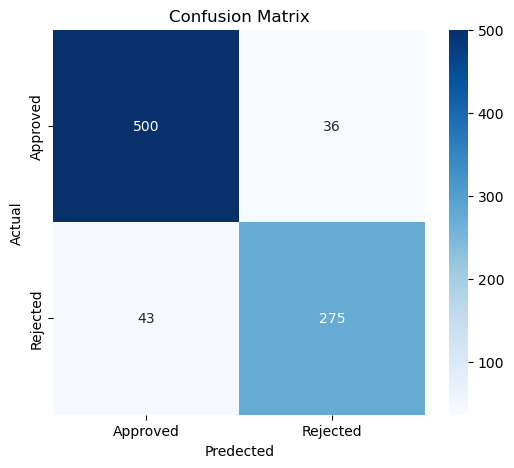

In [43]:
# Confusion Matrix heatmap
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
           annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved','Rejected']
           )

plt.xlabel("Predected")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

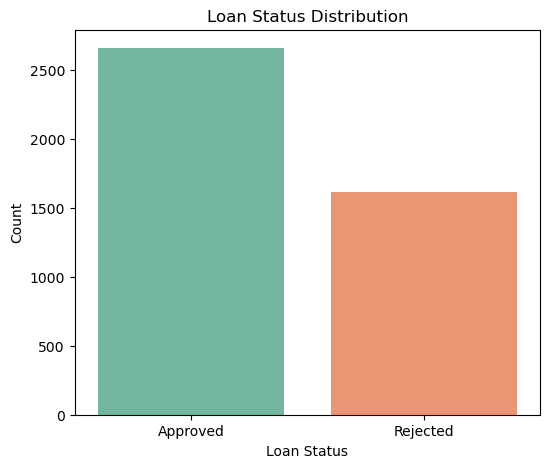

In [44]:
# Loan Status Distribution
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='loan_status',
    hue='loan_status',
    palette='Set2',
    legend=False
)

plt.xticks([0,1], ['Approved','Rejected'])
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

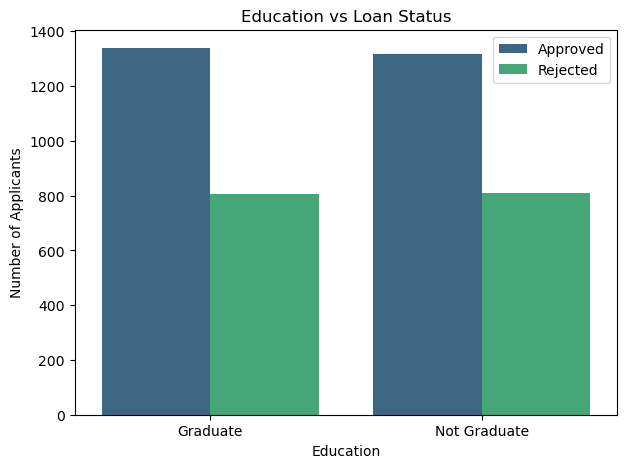

In [45]:
# Education vs Loan Status
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='education',
    hue='loan_status',
    palette='viridis'
)

plt.xticks([0,1], ['Graduate','Not Graduate'])
plt.legend(['Approved','Rejected'])

plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

plt.show()


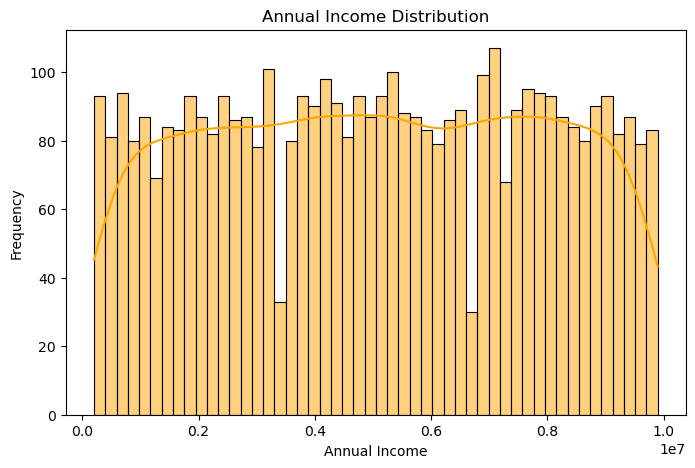

In [51]:
# Annual Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='income_annum',
    bins=50,
    kde=True,
    color='orange'
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()